# 🎬 Netflix Content Strategy Analysis

---

## 📌 Introduction
Netflix is one of the leading streaming platforms globally, offering a wide range of Movies and TV Shows across different genres and countries. Understanding content trends can provide insights into Netflix's business strategy and audience preferences.

---

## 🎯 Problem Statement
This project aims to analyze Netflix's content dataset to uncover patterns in:
- Content type distribution (Movies vs TV Shows)
- Growth of content over time
- Popular genres and categories
- Country-wise production trends
- Content ratings and audience targeting

---

## 🧠 Key Questions
- Does Netflix focus more on Movies or TV Shows?
- How has content production evolved over time?
- Which genres dominate the platform?
- Which countries produce the most content?
- What type of audience is Netflix targeting?

---

## 📂 Dataset Information
- Source: Kaggle Netflix Dataset
- Total Entries: ~8800 titles
- Features include:
  - Type (Movie/TV Show)
  - Title
  - Director, Cast
  - Country
  - Release Year
  - Rating
  - Duration
  - Genre (listed_in)

---

## 🛠️ Tools & Technologies
- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- Jupyter Notebook (VS Code)

---

In [496]:
# ================================
# 📦 Import Required Libraries
# ================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [497]:
import seaborn as sns

In [498]:
import sys
print(sys.executable)


c:\Users\Soumyadip Kumar\AppData\Local\Programs\Python\Python311\python.exe


In [499]:
import sys
!"""{sys.executable}""" -m pip install seaborn



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [500]:
import seaborn as sns

In [501]:
# ================================
# 📂 Load Dataset
# ================================

df = pd.read_csv("../data/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 🔍 Data Overview

In this section, we explore the structure, data types, and basic statistics of the dataset.

In [502]:
# ================================
# 🔍 Basic Data Inspection
# ================================

df.shape

(8807, 12)

In [503]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [504]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [505]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [506]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [507]:
# ================================
# 🎨 Visualization Settings
# ================================

# Set theme
sns.set_theme(style="whitegrid")

# Color palette
colors = sns.color_palette("Set2")

# Matplotlib settings
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 🧹 Data Cleaning

In this section, we handle missing values, fix data types, and prepare the dataset for analysis.

In [508]:
# ================================
# 🧹 Handling Missing Values
# ================================

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [509]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

0       United States
1        South Africa
2             Unknown
3             Unknown
4               India
            ...      
8802    United States
8803          Unknown
8804    United States
8805    United States
8806            India
Name: country, Length: 8807, dtype: str

In [510]:
df.dropna(subset=['date_added'], inplace=True)

In [511]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## ⚙️ Feature Engineering

In this section, we create new features from existing data to enable deeper analysis.

In [512]:
df['date_added'] = df['date_added'].str.strip()

In [513]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [514]:
df = df.dropna(subset=['date_added'])

In [515]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [516]:
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].str.replace('\d+', '', regex=True).str.strip()

In [517]:
df['country'] = df['country'].fillna('Unknown')

In [518]:
df['country_main'] = df['country'].apply(lambda x: str(x).split(',')[0])

In [519]:
df['genre'] = df['listed_in'].apply(lambda x: x.split(', '))

## 📊 Movies vs TV Shows Distribution

This visualization compares the number of Movies and TV Shows available on Netflix.

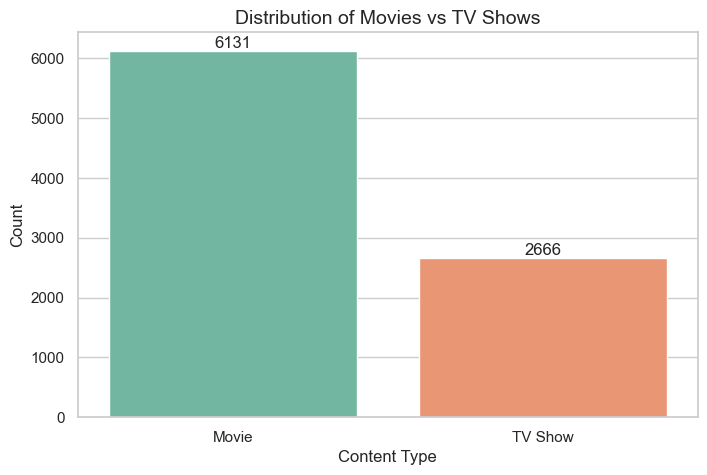

In [520]:
# ================================
# 📊 Movies vs TV Shows Count
# ================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='type',
    data=df,
    palette='Set2'
)

# Add title and labels
plt.title("Distribution of Movies vs TV Shows", fontsize=14)
plt.xlabel("Content Type")
plt.ylabel("Count")

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

## 📈 Content Growth Over Time

This visualization shows how Netflix has expanded its content library over the years.

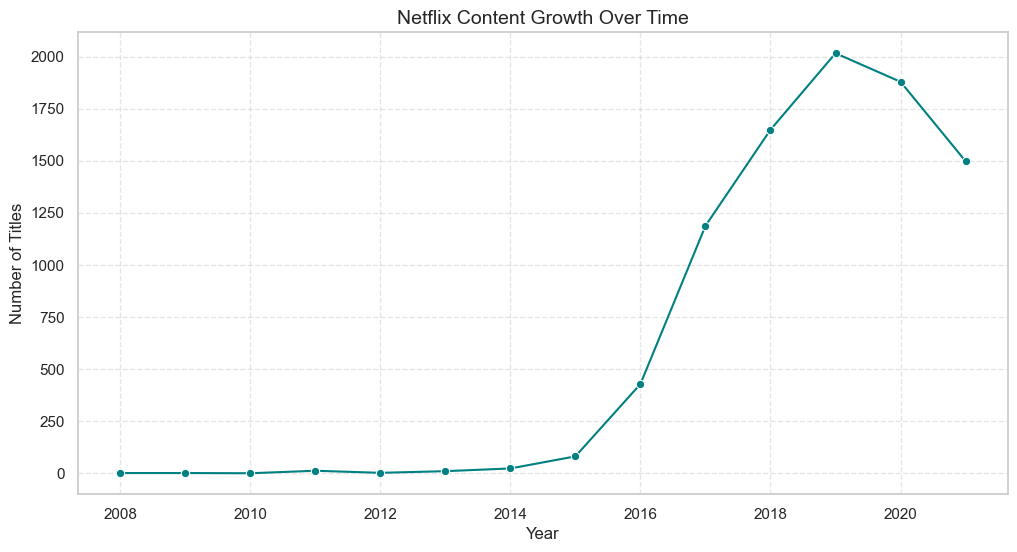

In [521]:
# ================================
# 📈 Content Growth Over Time
# ================================

# Count content by year
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o',
    color='teal'
)

# Titles and labels
plt.title("Netflix Content Growth Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Titles")

# Grid improvement
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 🌍 Top Producing Countries

This visualization highlights the countries that produce the most content available on Netflix.

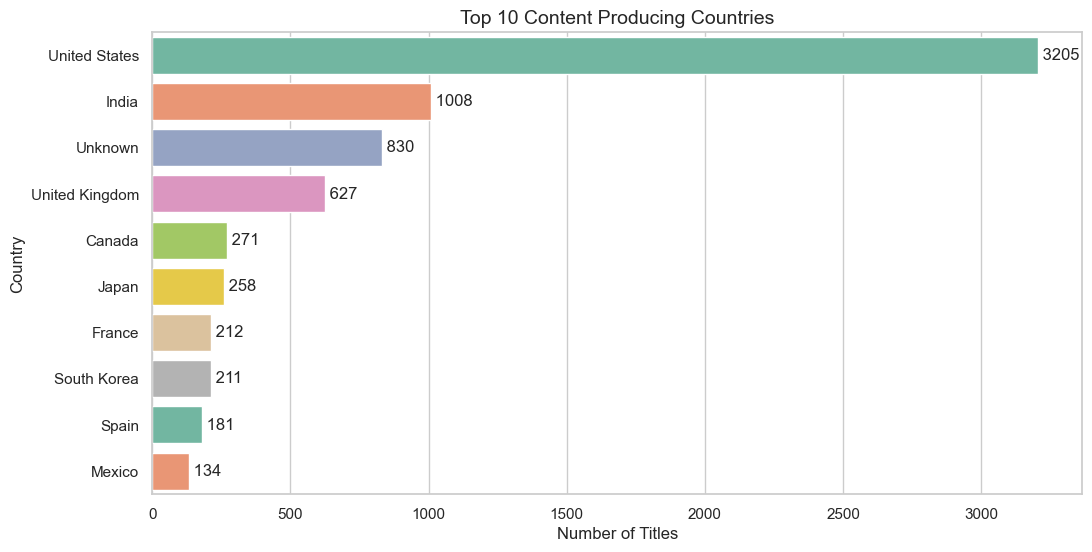

In [522]:
# ================================
# 🌍 Top Countries
# ================================

# Get top 10 countries
top_countries = df['country_main'].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='Set2'
)

# Titles and labels
plt.title("Top 10 Content Producing Countries", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Country")

# Add value labels
for i, v in enumerate(top_countries.values):
    plt.text(v, i, f' {v}', va='center')

plt.show()

## 🎭 Top Genres on Netflix

This analysis explores the most common genres available on Netflix by breaking down multi-genre entries.

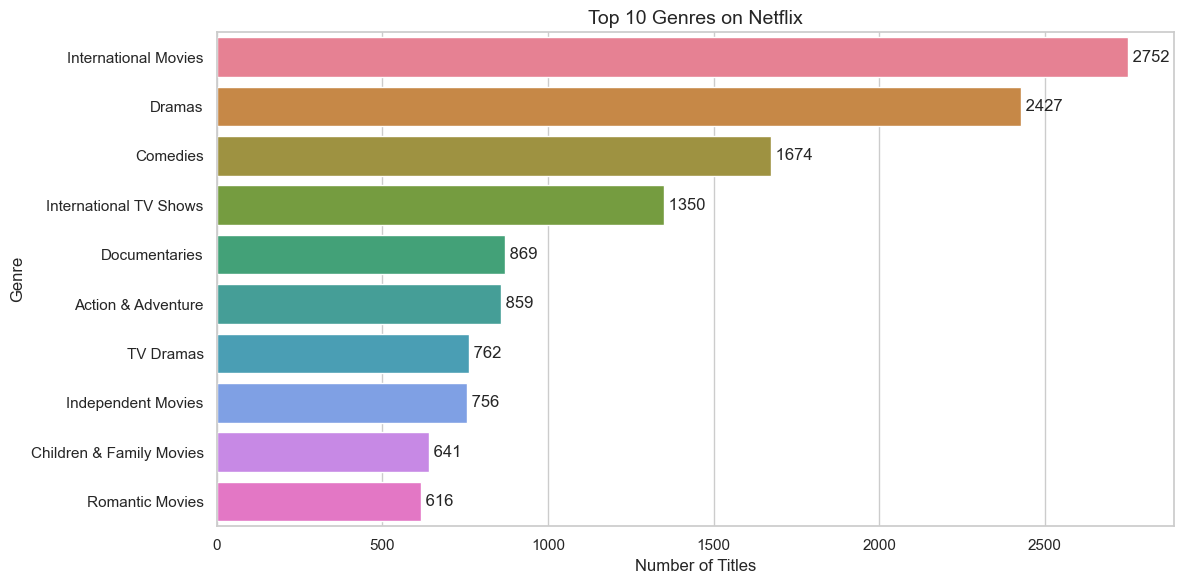

In [523]:
# ================================
# 🎭 Genre Analysis (Professional)
# ================================

# Explode genre column
genre_df = df.explode('genre')

# Get top 10 genres
top_genres = genre_df['genre'].value_counts().head(10)

plt.figure(figsize=(12,6))

# Dynamic color palette (different colors)
palette = sns.color_palette("husl", len(top_genres))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette=palette
)

# Titles and labels
plt.title("Top 10 Genres on Netflix", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

# Add value labels
for i, v in enumerate(top_genres.values):
    plt.text(v, i, f' {v}', va='center')

plt.tight_layout()
plt.show()

## 🎯 Content Rating Distribution

This visualization shows how Netflix content is distributed across different audience ratings.

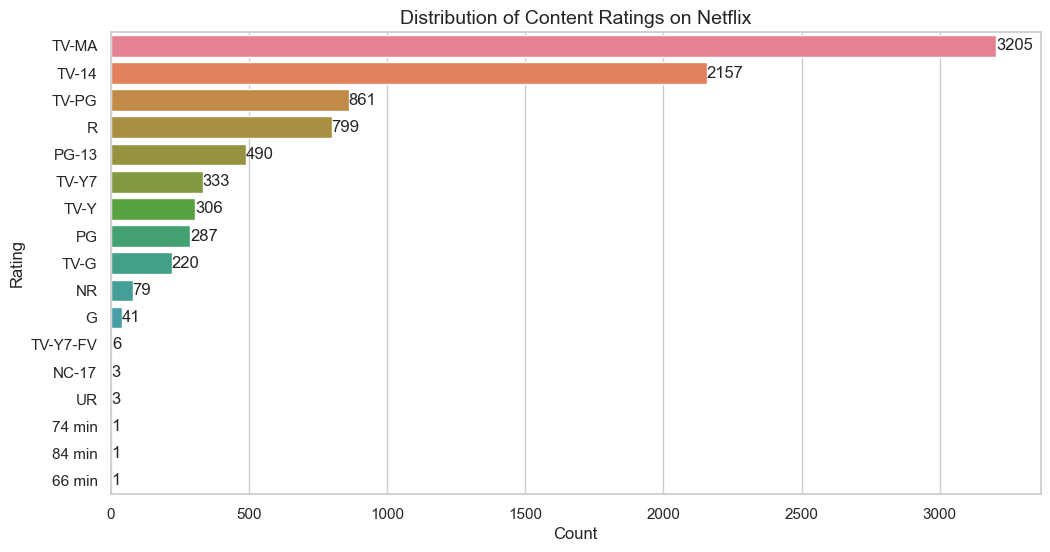

In [524]:
# ================================
# 🎯 Ratings Distribution
# ================================

plt.figure(figsize=(12,6))

palette = sns.color_palette("husl", len(df['rating'].unique()))

ax = sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index,
    palette=palette
)

# Titles and labels
plt.title("Distribution of Content Ratings on Netflix", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Rating")

# Add value labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width())}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        va='center'
    )

plt.show()

## ⏱️ Duration Analysis

This analysis compares the duration of Movies and TV Shows available on Netflix.

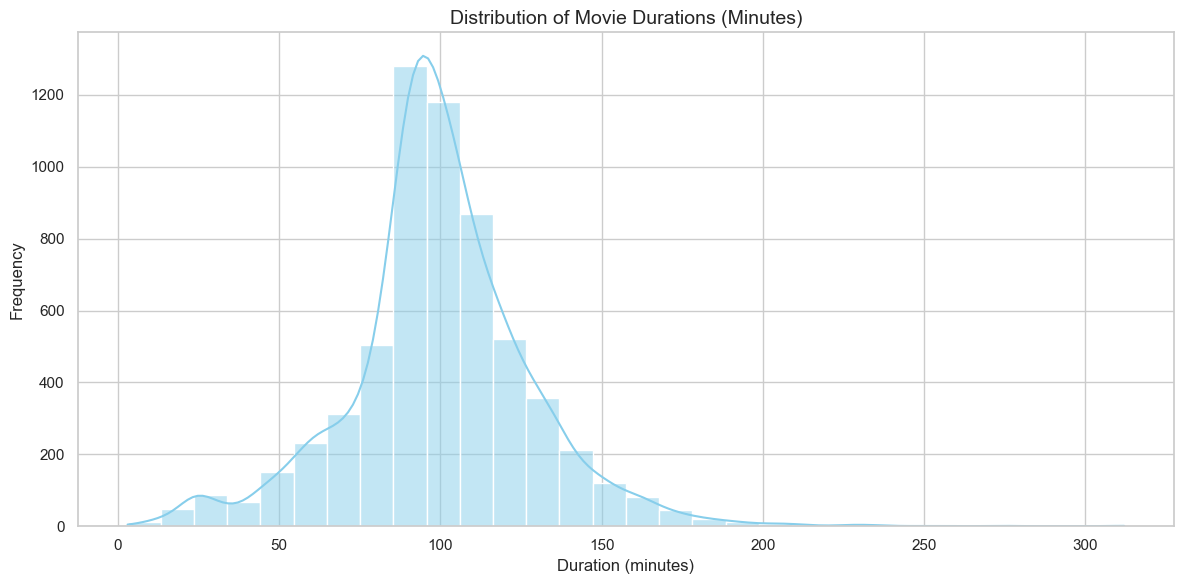

In [525]:
# ================================
# ⏱️ Movie Duration Analysis
# ================================

# Filter only movies
movies = df[df['type'] == 'Movie']

plt.figure(figsize=(12,6))

sns.histplot(
    movies['duration_int'],
    bins=30,
    kde=True,
    color='skyblue'
)

# Titles and labels
plt.title("Distribution of Movie Durations (Minutes)", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 📺 TV Shows Duration Analysis

This analysis explores the number of seasons for TV Shows available on Netflix.

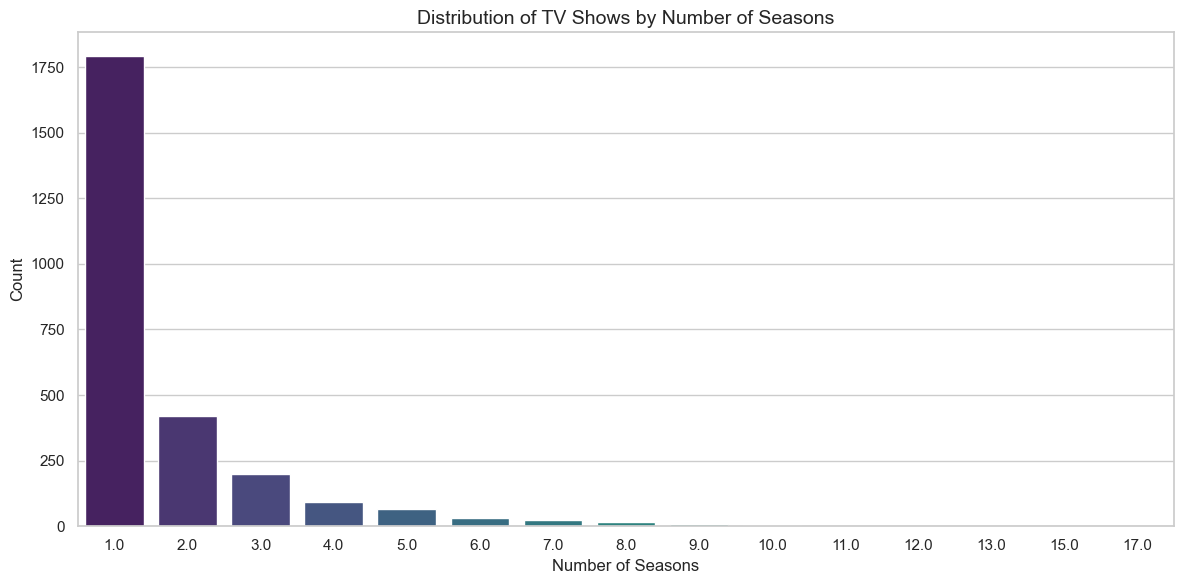

In [526]:
# ================================
# 📺 TV Shows Seasons Analysis
# ================================

# Filter TV Shows
tv_shows = df[df['type'] == 'TV Show']

plt.figure(figsize=(12,6))

sns.countplot(
    x='duration_int',
    data=tv_shows,
    palette='viridis'
)

# Titles and labels
plt.title("Distribution of TV Shows by Number of Seasons", fontsize=14)
plt.xlabel("Number of Seasons")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 🧠 Key Insights

Based on the analysis of Netflix content dataset, the following insights were observed:

### 📌 Content Type
- Netflix has a higher number of Movies compared to TV Shows.
- However, TV Shows have been increasing steadily over time.

### 📈 Growth Trend
- A significant rise in content addition is observed after 2015.
- Peak content addition occurred around 2018–2020.

### 🌍 Country Distribution
- United States dominates content production.
- India is among the top contributing countries.

### 🎭 Genre Analysis
- Drama and Comedy are the most common genres.
- International content is also widely present.

### 🎯 Audience Targeting
- Most content is rated TV-MA and TV-14.
- Indicates focus on adult and teenage audiences.

### ⏱️ Duration Insights
- Most movies are between 80–120 minutes.
- Most TV Shows have only 1–2 seasons.

---

## ✅ Conclusion

This analysis reveals that Netflix has rapidly expanded its content library, especially after 2015, with a strong focus on Movies. The platform primarily targets adult and teenage audiences, with Drama and Comedy being dominant genres.

Additionally, Netflix favors shorter TV series and standard-length movies, indicating a strategy focused on user engagement and content consumption patterns.

Overall, the data reflects Netflix's global expansion and its evolving content strategy to cater to diverse audiences.